# Fourier Analysis for Section VI.A

```bash
pip install timm==0.6.13
```

In [1]:
import math
import requests

import numpy as np 
import timm
from timm.data import IMAGENET_DEFAULT_MEAN, IMAGENET_DEFAULT_STD
from PIL import Image
from einops import rearrange

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


import torch
import torch.nn as nn 

from models import spanetv2_s18_pure, spanetv2_s18_hybrid

# Define utils 

In [2]:
imagenet_mean = np.array(IMAGENET_DEFAULT_MEAN)
imagenet_std = np.array(IMAGENET_DEFAULT_STD)

In [3]:
def show_image(image, title=''):
    # image is [H, W, 3]
    assert image.shape[2] == 3
    plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())
    plt.title(title, fontsize=16)
    plt.axis('off')
    return

# Modeal Load 

In [4]:
model_pure = spanetv2_s18_pure(pretrained=False) # can change different model name

checkpoint = torch.load('./ckpt/spanetv2_s18_pure_res-scale_Full-ExSPAM.pth', map_location='cpu')
model_pure.load_state_dict(checkpoint)

<All keys matched successfully>

In [5]:
model_hybrid = spanetv2_s18_hybrid(pretrained=False) # can change different model name

checkpoint2 = torch.load('./ckpt/spanetv2_s18_hybrid_k7_res-scale_Full-ExSPAM.pth', map_location='cpu')
model_hybrid.load_state_dict(checkpoint2)

<All keys matched successfully>

In [6]:
print(model_hybrid.__class__.__name__)

SPANetV2


# Inference in block-by-block 

In [7]:
# This cell build off https://github.com/facebookresearch/mae
import requests

/tmp/ipykernel_282394/3659196906.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  show_image(torch.tensor(xs[0]))
/tmp/ipykernel_282394/1897898895.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(torch.clip((image * imagenet_std + imagenet_mean) * 255, 0, 255).int())


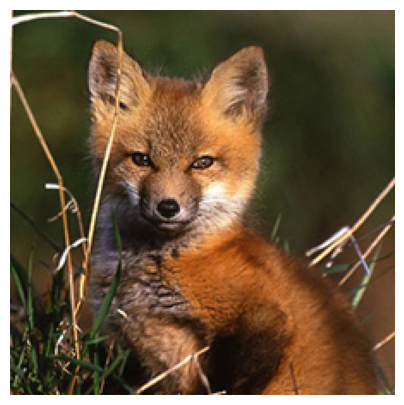

In [8]:
# -- load a sample ImageNet-1K image -- use the full val dataset for precise results
xs = [
    "https://user-images.githubusercontent.com/930317/158025258-e9a5a454-99de-4d22-bc93-b217cdf06abb.jpeg",
]

xs = [Image.open(requests.get(x, stream=True).raw) for x in xs]
xs = [x.resize((224, 224)) for x in xs]
xs = [np.array(x) / 255. for x in xs]
xs = np.stack(xs, axis=0)  # (B,H,W,C)

assert xs.shape[1:] == (224, 224, 3)


# -- normalize by ImageNet mean and std
xs = xs - imagenet_mean
xs = xs / imagenet_std
xs = torch.tensor(xs, dtype=torch.float32)

plt.rcParams['figure.figsize'] = [5, 5]
show_image(torch.tensor(xs[0]))

In [9]:
xs1 = torch.tensor(xs, dtype=torch.float32).permute(0,-1,1,2) # (B,C,H,W)
xs2 = torch.tensor(xs, dtype=torch.float32).permute(0,-1,1,2) # (B,C,H,W)

/tmp/ipykernel_282394/1394060193.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs1 = torch.tensor(xs, dtype=torch.float32).permute(0,-1,1,2) # (B,C,H,W)
/tmp/ipykernel_282394/1394060193.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xs2 = torch.tensor(xs, dtype=torch.float32).permute(0,-1,1,2) # (B,C,H,W)


In [10]:
pure_blocks = [
    model_pure.downsample_layers[0],
    *model_pure.stages[0], 
    model_pure.downsample_layers[1],
    *model_pure.stages[1],     
    model_pure.downsample_layers[2],
    *model_pure.stages[2],        
    model_pure.downsample_layers[3],
    *model_pure.stages[3]        
]


# accumulate `latents` by collecting hidden states of a model
pure_latents = []
with torch.no_grad():
    for block in pure_blocks:
        xs1 = block(xs1)
        pure_latents.append(xs1)


In [11]:
hybrid_blocks = [
    model_hybrid.downsample_layers[0],
    *model_hybrid.stages[0], 
    model_hybrid.downsample_layers[1],
    *model_hybrid.stages[1],     
    model_hybrid.downsample_layers[2],
    *model_hybrid.stages[2],        
    model_hybrid.downsample_layers[3],
    *model_hybrid.stages[3]        
]


# accumulate `latents` by collecting hidden states of a model
hybrid_latents = []
with torch.no_grad():
    for block in hybrid_blocks:
        xs2 = block(xs2)
        hybrid_latents.append(xs2)

# Plot Fourier Transformed Feature Maps 

In [12]:
def fourier(x):  # 2D Fourier transform
    f = torch.fft.fft2(x)
    f = f.abs() + 1e-6  # Amplitude 
    f = f.log()         # Log
    return f


def shift(x):  # shift Fourier transformed feature map
    b, c, h, w = x.shape
    return torch.roll(x, shifts=(int(h/2), int(w/2)), dims=(2, 3))

## Relative-log Amplitude 

$\Delta \text{LogAmp}(f_{i})=\text{LogAmp}(f_{i}) - \text{LogAmp}(f_{0})=log(\frac{\text{amp}(f_{i})}{\text{amp}(f_{0})})$

In [13]:
fourier_latents = []

for latent in pure_latents:
    latent = latent.detach().cpu().contiguous()

    if len(latent.shape) == 3:  # for ViT
        b, n, c = latent.shape
        h, w = int(math.sqrt(n)), int(math.sqrt(n))
        latent = rearrange(latent, "b (h w) c -> b c h w", h=h, w=w)
    
    elif len(latent.shape) == 4:  # for SPANetV2
        b, h, w, c = latent.shape
        latent = rearrange(latent, "b h w c -> b c h w", h=h, w=w)

    else:
        raise Exception(f"shape: {str(latent.shape)}")
    
    latent = fourier(latent)
    latent = shift(latent).mean(dim=(0, 1)) # (B,C,H,W) -> (H,W); Centering the low-frequency
    
#    plt.imshow(latent)
#    plt.show()
    latent = latent.diag()[int(h/2):]  # only use the half-diagonal components
                                       # low-freq => high-freq 

    latent = latent - latent[0]  # visualize 'relative' log amplitudes 
                                 # (i.e., current-freq_amp - low-freq_amp)
    fourier_latents.append(latent)

0 28
1 28
2 28
3 28
4 14
5 14
6 14
7 14
8 7
9 7
10 7
11 7
12 7
13 7
14 7
15 7
16 7
17 7
18 4
19 4
20 4
21 4


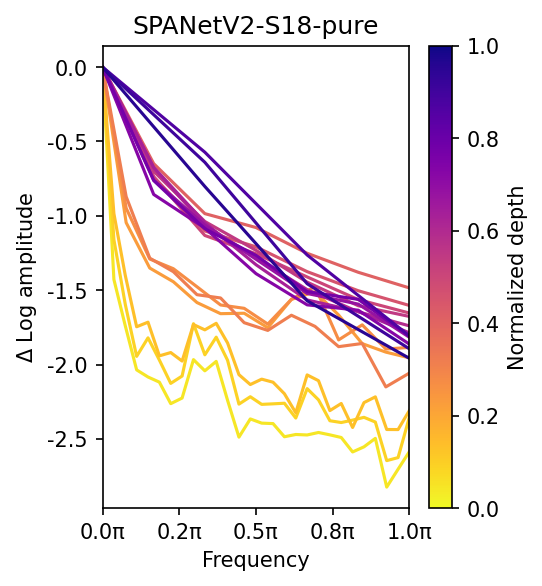

In [14]:
fig, ax1 = plt.subplots(1, 1, figsize=(3.3, 4), dpi=150)

num_layers = len(fourier_latents)

for i, latent in enumerate(fourier_latents):
    print(i,len(latent))
    if i not in [0, 4, 8, 18]:
        freq = np.linspace(0, 1, len(latent))
        normalized_depth = i / num_layers  #  range in 0~1 
        ax1.plot(freq, latent, color=cm.plasma_r(normalized_depth))           
    else:
        continue



ax1.set_xlim(left=0, right=1)
ax1.set_xlabel("Frequency")
ax1.set_ylabel("$\Delta$ Log amplitude")
ax1.set_title("SPANetV2-S18-pure")

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1fπ'))


# Color bar 
norm = mcolors.Normalize(vmin=0, vmax=1)  # 정규화 (0~1)
sm = cm.ScalarMappable(cmap=cm.plasma_r, norm=norm)
sm.set_array([])  # 컬러바를 위한 빈 배열 설정
cbar = fig.colorbar(sm, ax=ax1, orientation="vertical")
cbar.set_label("Normalized depth")


plt.savefig("./misc/Relative_log_amp_SPANetV2-S18-pure.png", dpi=300, bbox_inches='tight')

In [15]:
fourier_latents = []

for latent in hybrid_latents:
    latent = latent.detach().cpu().contiguous()

    if len(latent.shape) == 3:  # for ViT
        b, n, c = latent.shape
        h, w = int(math.sqrt(n)), int(math.sqrt(n))
        latent = rearrange(latent, "b (h w) c -> b c h w", h=h, w=w)
    
    elif len(latent.shape) == 4:  # for SPANetV2
        b, h, w, c = latent.shape
        latent = rearrange(latent, "b h w c -> b c h w", h=h, w=w)

    else:
        raise Exception(f"shape: {str(latent.shape)}")
    
    latent = fourier(latent)
    latent = shift(latent).mean(dim=(0, 1)) # (B,C,H,W) -> (H,W); Centering the low-frequency
#    plt.imshow(latent)
#    plt.show()
    latent = latent.diag()[int(h/2):]  # only use the half-diagonal components
                                       # low-freq => high-freq 

    latent = latent - latent[0]  # visualize 'relative' log amplitudes 
                                 # (i.e., current-freq_amp - low-freq_amp)
    fourier_latents.append(latent)

0 28
1 28
2 28
3 28
4 14
5 14
6 14
7 14
8 7
9 7
10 7
11 7
12 7
13 7
14 7
15 7
16 7
17 7
18 4
19 4
20 4
21 4


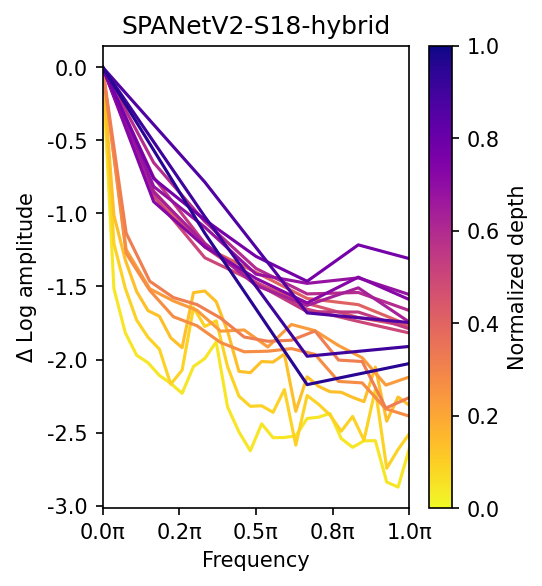

In [16]:
fig, ax1 = plt.subplots(1, 1, figsize=(3.3, 4), dpi=150)

num_layers = len(fourier_latents)

for i, latent in enumerate(fourier_latents):
    print(i,len(latent))
    if i not in [0, 4, 8, 18]:
        freq = np.linspace(0, 1, len(latent))
        normalized_depth = i / num_layers  #  range in 0~1 
        ax1.plot(freq, latent, color=cm.plasma_r(normalized_depth))           
    else:
        continue



ax1.set_xlim(left=0, right=1)
ax1.set_xlabel("Frequency")
ax1.set_ylabel("$\Delta$ Log amplitude")
ax1.set_title("SPANetV2-S18-hybrid")

ax1.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
ax1.xaxis.set_major_formatter(FormatStrFormatter('%.1fπ'))



# Color bar 
norm = mcolors.Normalize(vmin=0, vmax=1)  # 정규화 (0~1)
sm = cm.ScalarMappable(cmap=cm.plasma_r, norm=norm)
sm.set_array([])  # 컬러바를 위한 빈 배열 설정
cbar = fig.colorbar(sm, ax=ax1, orientation="vertical")
cbar.set_label("Normalized depth")


plt.savefig("./misc/Relative_log_amp_SPANetV2-S18-hybrid.png", dpi=300, bbox_inches='tight')